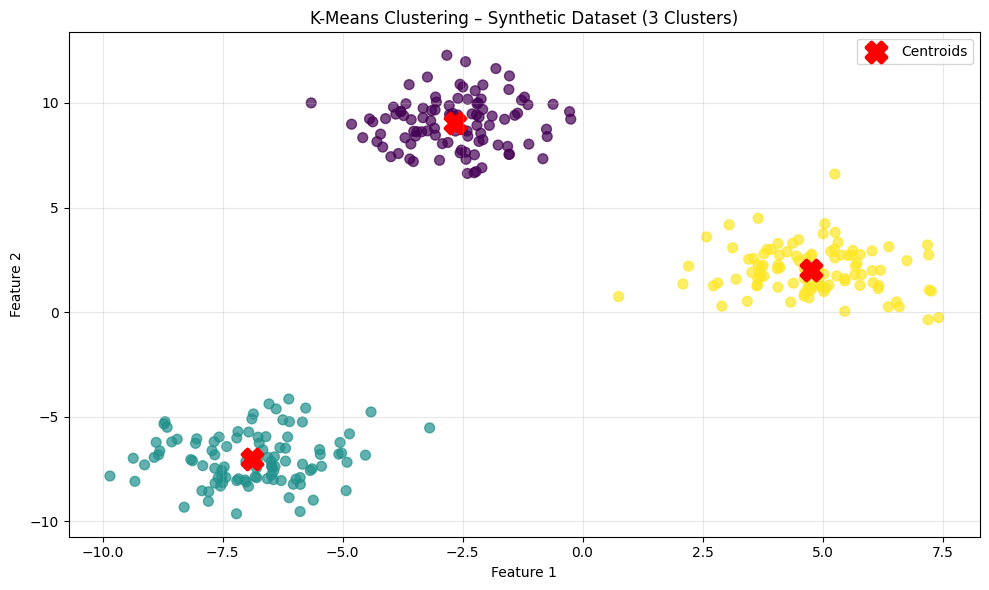

Clustered data exported to 'clustered_data.csv'
Dataset shape: (300, 3)

Cluster distribution:
 Cluster
0    100
1    100
2    100
Name: count, dtype: int64


In [3]:
# Assignment 4: K-Means Clustering on Synthetic Dataset + Tableau Histograms
# Reference: Kaggle 2D Clustering Dataset Collection

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import pandas as pd

# Step 1: Generate synthetic 2D dataset
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Step 3: Visualize clusters [file:139]
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='red', marker='X', s=200, linewidths=3, label='Centroids')
plt.title("K-Means Clustering – Synthetic Dataset (3 Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 4: Export clustered data for Tableau
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df['Cluster'] = clusters
df.to_csv("clustered_data.csv", index=False)
print("Clustered data exported to 'clustered_data.csv'")
print("Dataset shape:", df.shape)
print("\nCluster distribution:\n", df['Cluster'].value_counts().sort_index())
